# 03 — The ablation ladder: what each pipeline change is worth

Notebook 02 built one wide matrix. This notebook cuts six column subsets out of it and trains the same
model on each, changing **exactly one thing per rung**:

| rung | change | metrics × aggregations | columns |
|---|---|---|---|
| **A** | Session 1's feature set, reproduced | 8 inherited (counters raw) × `min max mean std` | 32 |
| **B** | counters become **rates** | the same 8, three of them differenced × `min max mean std` | 32 |
| **C** | **more metrics** — GPU duty cycle, free memory, blocked procs, error rates, spreads | 36 × `min max mean std` | 144 |
| **D** | **trajectory** — `last`, `delta`, `slope` on top | 36 × 7 aggregations | 252 |
| **E** | **per-node normalisation** of D | 36 × 7, node-standardised | 252 |
| **F** | **node identity** as a feature, on top of D | D + `node_id` | 253 |

Everything else is held constant: the same rows, the same window, the same labels, the same LightGBM
configuration, the same protocol. Rung A exists to prove the rebuilt pipeline reproduces the old one
before anything is credited to the changes.

**Protocol** — the Session-2 invariants, applied identically to every rung:

* fit on the earlier part of train; early-stop on a **temporal holdout** = the most recent 15 % of train
  windows, with every job that appears in it removed from the fit set and a 2 h embargo before the
  boundary (a window's label looks up to one horizon into the future);
* early stopping watches **average precision**, not log-loss;
* the operating threshold is chosen on that holdout, never on test;
* the test set is touched exactly once per rung, to report.

The models here train on ~85 % of train (the holdout is held out). Notebook 06 refits the winner on all of
it, so its number is not directly comparable with a rung.

In [1]:
import sys, json, time, gc
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()

d_tr = pv2.load_dataset("primary", "train")
d_te = pv2.load_dataset("primary", "test")
base = pv2.load_baseline("primary")
feats = d_tr["features"]

fit, val = pv2.temporal_holdout(d_tr["t_end"], d_tr["job_id"])
print(f"train windows {len(d_tr['y']):,}")
print(f"  fit {fit.sum():>9,}  ({d_tr['y'][fit].mean():.4f} positive)  "
      f"up to {pd.to_datetime(d_tr['t_end'][fit].max())}")
print(f"  val {val.sum():>9,}  ({d_tr['y'][val].mean():.4f} positive)  "
      f"from {pd.to_datetime(d_tr['t_end'][val].min())}")
print(f"  jobs shared between fit and val: "
      f"{len(set(d_tr['job_id'][fit]) & set(d_tr['job_id'][val]))}")
print(f"test windows {len(d_te['y']):,}  ({d_te['y'].mean():.4f} positive = the PR-AUC baseline)")
BASELINE = float(d_te["y"].mean())

train windows 1,825,415
  fit 1,521,814  (0.0328 positive)  up to 2022-10-11 23:51:00
  val   273,826  (0.0324 positive)  from 2022-10-12 01:51:30
  jobs shared between fit and val: 0


test windows 1,407,162  (0.0402 positive = the PR-AUC baseline)


## 1. Define the rungs

In [2]:
V1_RAW = [m for m in pv2.METRIC_NAMES if pv2.METRIC_GROUP[m] == "v1"]
V1_RATE = ["mem_active", "disk_written_rate", "tcp_inerrs_rate", "forks_rate",
           "gpu_temp_mean", "gpu_power_mean", "gpu_mem_used", "gpu_fan_mean"]
ALL_METRICS = [m for m in pv2.METRIC_NAMES if not m.endswith("_cum")]   # drop the raw counters
# rung G keeps the raw levels AND adds a node-standardised copy of each of these
LEVEL_METRICS = ["gpu_temp_mean", "gpu_temp_max", "gpu_power_mean", "gpu_mem_used",
                 "gpu_fan_mean", "gpu_duty_mean", "mem_active", "mem_free", "load1",
                 "load15", "hwmon_temp_max", "node_power"]

RUNGS = [
    dict(key="A", label="v1 replica", metrics=V1_RAW,      aggs=pv2.AGGS_V1),
    dict(key="B", label="+ rates",    metrics=V1_RATE,     aggs=pv2.AGGS_V1),
    dict(key="C", label="+ metrics",  metrics=ALL_METRICS, aggs=pv2.AGGS_V1),
    dict(key="D", label="+ trajectory", metrics=ALL_METRICS, aggs=pv2.AGGS),
    dict(key="E", label="+ node norm", metrics=ALL_METRICS, aggs=pv2.AGGS, node_norm=True),
    dict(key="F", label="+ node id",   metrics=ALL_METRICS, aggs=pv2.AGGS, add_node=True),
    dict(key="G", label="+ node deltas", metrics=ALL_METRICS, aggs=pv2.AGGS,
         norm_metrics=LEVEL_METRICS),
]
for r in RUNGS:
    r["cols"] = pv2.column_index(feats, metrics=r["metrics"], aggs=r["aggs"])
    r["norm_cols"] = (pv2.column_index(feats, metrics=r["norm_metrics"], aggs=r["aggs"])
                      if r.get("norm_metrics") else None)
    r["n_features"] = (len(r["cols"]) + int(r.get("add_node", False))
                       + (0 if r["norm_cols"] is None else len(r["norm_cols"])))
print(pd.DataFrame([{k: r[k] for k in ("key", "label", "n_features")} for r in RUNGS])
        .to_string(index=False))
print(f"\nrung C/D metric set ({len(ALL_METRICS)}): " + ", ".join(ALL_METRICS))

key         label  n_features
  A    v1 replica          32
  B       + rates          32
  C     + metrics         144
  D  + trajectory         252
  E   + node norm         252
  F     + node id         253
  G + node deltas         336

rung C/D metric set (36): mem_active, gpu_temp_mean, gpu_power_mean, gpu_mem_used, gpu_fan_mean, disk_written_rate, tcp_inerrs_rate, forks_rate, ctxsw_rate, intr_rate, disk_read_rate, disk_wcompl_rate, net_tx_rate, net_rx_rate, net_rxdrop_rate, tcp_retrans_rate, icmp_inerr_rate, rapl_power, gpu_duty_mean, gpu_duty_min, gpu_temp_max, gpu_temp_spread, gpu_power_max, gpu_power_spread, gpu_fan_max, mem_free, mem_dirty, load1, load15, procs_running, procs_blocked, hwmon_temp_max, thermal_max, node_power, fs_avail, disk_io_now


## 2. Train and score

Each rung: materialise its columns, fit with temporal early stopping, pick the operating threshold on the
holdout, then score the test set once. Results are cached — re-running the notebook does not retrain.

In [3]:
SCORE_DIR = pv2.ARTIFACTS / "scores"; SCORE_DIR.mkdir(exist_ok=True)
CACHE = pv2.RESULTS / "ablation.json"
done = json.loads(CACHE.read_text()) if CACHE.exists() else {}

def run_rung(r, force=False):
    if r["key"] in done and not force:
        print(f"[{r['key']}] cached"); return done[r["key"]]
    t0 = time.time()
    kw = dict(node_norm=r.get("node_norm", False), baseline=base,
              add_node=r.get("add_node", False), norm_cols=r.get("norm_cols"))
    Xf = pv2.materialise(d_tr, r["cols"], fit, **kw)
    Xv = pv2.materialise(d_tr, r["cols"], val, **kw)
    yf, yv = d_tr["y"][fit], d_tr["y"][val]
    bst = pv2.train_lgbm(Xf, yf, Xv, yv, rounds=800, patience=50)
    del Xf; gc.collect()
    sv = bst.predict(Xv, num_iteration=bst.best_iteration)
    del Xv; gc.collect()
    # operating threshold picked on the holdout, never on test
    th, f2v, _, _ = pv2.best_threshold(yv, sv, beta=2.0)
    st = pv2.predict_split(bst, d_te, r["cols"], num_iteration=bst.best_iteration, **kw)
    np.save(SCORE_DIR / f"ablation_{r['key']}.npy", st.astype(np.float32))
    res = pv2.evaluate(d_te["y"], st, d_te["state"], threshold=th)
    res |= {"key": r["key"], "label": r["label"], "n_features": r["n_features"],
            "rounds": int(bst.best_iteration),
            "val_ap": float(bst.best_score["valid_0"]["average_precision"]),
            "seconds": round(time.time() - t0, 1)}
    done[r["key"]] = res
    CACHE.write_text(json.dumps(done, indent=2))
    print(f"[{r['key']}] {r['label']:<15} feats {r['n_features']:>3} | rounds {res['rounds']:>3} | "
          f"val AP {res['val_ap']:.4f} | TEST PR-AUC {res['pr_auc']:.4f} "
          f"({res['lift']:.2f}x) | {res['seconds']:.0f}s")
    del bst; gc.collect()
    return res

for r in RUNGS:
    run_rung(r)

[A] cached
[B] cached
[C] cached
[D] cached
[E] cached
[F] cached
[G] cached


In [4]:
tab = pd.DataFrame([done[r["key"]] for r in RUNGS])
tab["delta_vs_A"] = tab.pr_auc - tab.pr_auc.iloc[0]
show = tab[["key", "label", "n_features", "rounds", "val_ap", "pr_auc", "lift",
            "delta_vs_A", "roc_auc"]]
print(show.to_string(index=False, formatters={
    "val_ap": "{:.4f}".format, "pr_auc": "{:.4f}".format, "lift": "{:.2f}x".format,
    "delta_vs_A": "{:+.4f}".format, "roc_auc": "{:.3f}".format}))
print(f"\nPR-AUC baseline (random) = {BASELINE:.4f}")
print("Session 1 best 0.0795 (1.97x) | Session 2 best 0.0860 (2.13x), both on ~the same test set")

key         label  n_features  rounds val_ap pr_auc  lift delta_vs_A roc_auc
  A    v1 replica          32      93 0.1182 0.0726 1.81x    +0.0000   0.602
  B       + rates          32     102 0.1330 0.0788 1.96x    +0.0062   0.612
  C     + metrics         144     141 0.1659 0.1382 3.44x    +0.0657   0.619
  D  + trajectory         252     151 0.1712 0.1316 3.28x    +0.0590   0.622
  E   + node norm         252      94 0.1447 0.0837 2.08x    +0.0111   0.615
  F     + node id         253      79 0.1661 0.1172 2.92x    +0.0446   0.625
  G + node deltas         336     241 0.1714 0.1239 3.08x    +0.0514   0.631

PR-AUC baseline (random) = 0.0402
Session 1 best 0.0795 (1.97x) | Session 2 best 0.0860 (2.13x), both on ~the same test set


## 3. Where the gain comes from

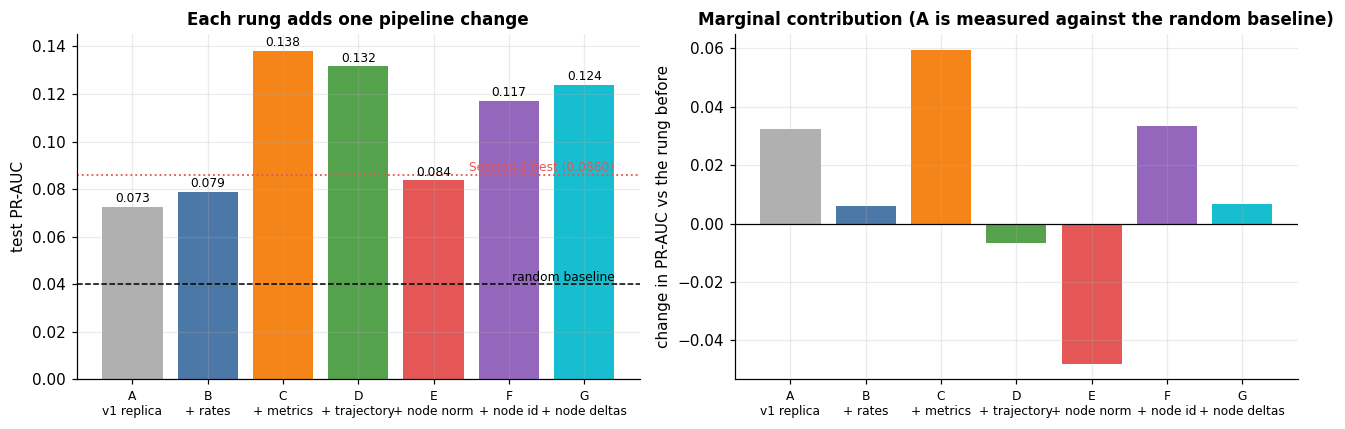

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
colors = [pv2.PALETTE["muted"], pv2.PALETTE["rate"], pv2.PALETTE["gpu"],
          pv2.PALETTE["node"], pv2.PALETTE["accent"], "#9467bd", "#17becf"]
b = ax.bar(tab.key, tab.pr_auc, color=colors)
ax.axhline(BASELINE, color="k", ls="--", lw=1)
ax.text(len(tab) - 0.6, BASELINE, "random baseline", ha="right", va="bottom", fontsize=8)
ax.axhline(0.0860, color=pv2.PALETTE["accent"], ls=":", lw=1.2)
ax.text(len(tab) - 0.6, 0.0865, "Session 2 best (0.0860)", ha="right", va="bottom", fontsize=8,
        color=pv2.PALETTE["accent"])
for rect, v, lab in zip(b, tab.pr_auc, tab.label):
    ax.text(rect.get_x() + rect.get_width()/2, v + .002, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(range(len(tab)))
ax.set_xticklabels([f"{k}\n{l}" for k, l in zip(tab.key, tab.label)], fontsize=8)
ax.set_ylabel("test PR-AUC"); ax.set_title("Each rung adds one pipeline change")

ax = axes[1]
step = tab.pr_auc.diff().fillna(tab.pr_auc.iloc[0] - BASELINE)
ax.bar(tab.key, step, color=colors)
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("change in PR-AUC vs the rung before")
ax.set_title("Marginal contribution (A is measured against the random baseline)")
ax.set_xticks(range(len(tab)))
ax.set_xticklabels([f"{k}\n{l}" for k, l in zip(tab.key, tab.label)], fontsize=8)
fig.savefig(pv2.FIGURES / "03_ablation.png", bbox_inches="tight")
plt.show()

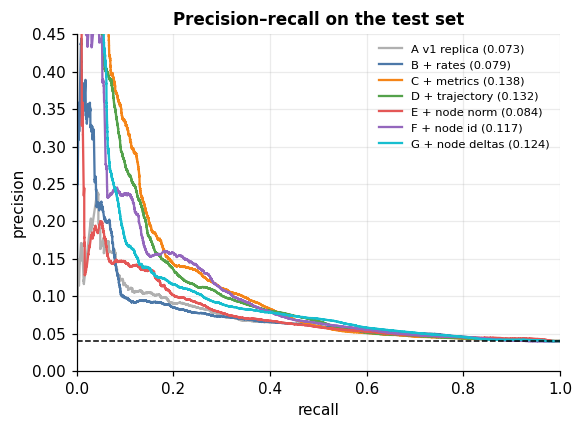

In [6]:
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(5.4, 4))
for r, c in zip(RUNGS, colors):
    s = np.load(SCORE_DIR / f"ablation_{r['key']}.npy")
    p, rc, _ = precision_recall_curve(d_te["y"], s)
    ax.plot(rc, p, lw=1.5, color=c, label=f"{r['key']} {r['label']} "
                                          f"({done[r['key']]['pr_auc']:.3f})")
ax.axhline(BASELINE, color="k", ls="--", lw=1)
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, .45)
ax.set_title("Precision–recall on the test set")
ax.legend(fontsize=7.5)
fig.savefig(pv2.FIGURES / "03_pr_curves.png", bbox_inches="tight")
plt.show()

## 4. Per-state recall

The thesis question is not only *how much* signal there is but *which failures* it catches. Recall is
measured at each rung's own F2 threshold — chosen on the temporal holdout, so still test-blind.

In [7]:
cols_state = [f"recall_{pv2.STATE_DISPLAY[s]}" for s in pv2.REPORT_STATES]
ps = tab[["key", "label", "precision", "recall", "fbeta"] + cols_state].copy()
ps.columns = ["key", "label", "precision", "recall", "F2"] + \
             [pv2.STATE_DISPLAY[s] for s in pv2.REPORT_STATES]
print(ps.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\n(recall at each rung's own F2 threshold, chosen on the temporal holdout)")
print("Session 1 reported, per state: OOM ~0.66, TIMEOUT ~0.52, FAILED ~0.42, NODE_FAIL ~0.40")

key         label  precision  recall    F2  TIMEOUT  FAILED   OOM  NODE_FAIL
  A    v1 replica      0.058   0.529 0.201    0.545   0.438 0.835      0.539
  B       + rates      0.066   0.381 0.196    0.387   0.309 0.735      0.427
  C     + metrics      0.068   0.458 0.213    0.473   0.376 0.859      0.372
  D  + trajectory      0.072   0.468 0.222    0.484   0.369 0.830      0.490
  E   + node norm      0.065   0.423 0.201    0.433   0.321 0.882      0.484
  F     + node id      0.080   0.396 0.222    0.401   0.321 0.851      0.414
  G + node deltas      0.078   0.400 0.220    0.413   0.316 0.854      0.334

(recall at each rung's own F2 threshold, chosen on the temporal holdout)
Session 1 reported, per state: OOM ~0.66, TIMEOUT ~0.52, FAILED ~0.42, NODE_FAIL ~0.40


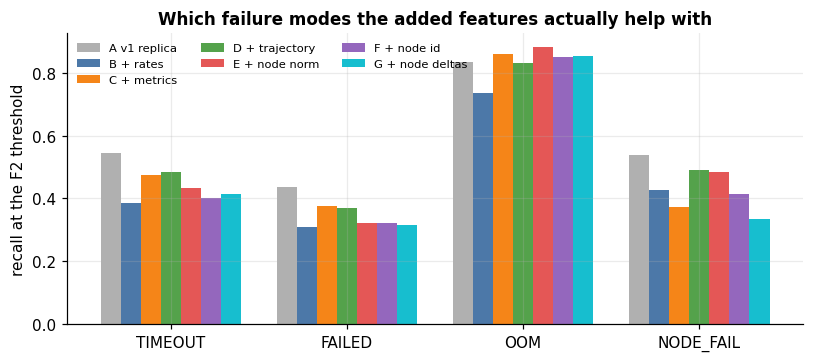

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.arange(len(pv2.REPORT_STATES)); w = 0.8 / len(RUNGS)
for i, (r, c) in enumerate(zip(RUNGS, colors)):
    v = [done[r["key"]][f"recall_{pv2.STATE_DISPLAY[s]}"] for s in pv2.REPORT_STATES]
    ax.bar(x + (i - (len(RUNGS)-1)/2) * w, v, w, label=f"{r['key']} {r['label']}", color=c)
ax.set_xticks(x); ax.set_xticklabels([pv2.STATE_DISPLAY[s] for s in pv2.REPORT_STATES])
ax.set_ylabel("recall at the F2 threshold"); ax.legend(fontsize=7.5, ncol=3)
ax.set_title("Which failure modes the added features actually help with")
fig.savefig(pv2.FIGURES / "03_per_state_recall.png", bbox_inches="tight")
plt.show()

## 5. A warning that falls out of the table

Compare the two score columns. The **temporal holdout** ranks the rungs
`G ≈ D > F ≈ C ≫ E ≫ B > A`; the **test set** ranks them `C > D > G > F ≫ E ≈ B > A`. The holdout picks
the right *region* — everything from C upwards is far above the old feature set — but it cannot reliably
order the leaders, and it prefers the widest feature sets while the test set prefers the leanest of the
strong ones.

That is not a contradiction, it is the shape of the problem: the holdout is **one** 10-day period, and
which extra columns help is period-specific. Session 2 already showed that a single monitor can mislead
(same-period validation chose ~260 boosting rounds where the future preferred ~120). The lesson here is
narrower and new: a single temporal holdout is fine for **stopping** a model, but too noisy for **choosing
between feature sets**. Notebook 04 therefore selects over several purged folds instead of one.

In [9]:
from scipy.stats import spearmanr
rho = spearmanr(tab.val_ap, tab.pr_auc).statistic
print(f"Spearman correlation between holdout AP and test PR-AUC across rungs: {rho:.2f}")
print("holdout ranking: " + " > ".join(tab.sort_values("val_ap", ascending=False).key))
print("test    ranking: " + " > ".join(tab.sort_values("pr_auc", ascending=False).key))
bl = tab.loc[tab.val_ap.idxmax()]
bt = tab.loc[tab.pr_auc.idxmax()]
print()
print(f"test-blind pick (best holdout AP): rung {bl.key} -> test PR-AUC "
      f"{bl.pr_auc:.4f} ({bl.lift:.2f}x)")
print(f"best test rung in hindsight:       rung {bt.key} -> test PR-AUC "
      f"{bt.pr_auc:.4f} ({bt.lift:.2f}x)")

Spearman correlation between holdout AP and test PR-AUC across rungs: 0.75
holdout ranking: G > D > F > C > E > B > A
test    ranking: C > D > G > F > E > B > A

test-blind pick (best holdout AP): rung G -> test PR-AUC 0.1239 (3.08x)
best test rung in hindsight:       rung C -> test PR-AUC 0.1382 (3.44x)


## 6. Reading the ladder

* **A — the replica lands at 0.0726**, a little under the 0.0795 Session 1 reported with the same eight
  metrics. Expected: this rung trains on ~85 % of a train set that is itself strided 1-in-5, with one
  fixed untuned LightGBM, where Session 1 fitted every window. The point of A is not to match to three
  decimals but to confirm that the rebuilt rows and labels behave like the old ones — they do.

* **B — counters as rates: +0.006 (+9 %) for free.** Same eight metrics, same 32 columns, same model; the
  only change is differencing three cumulative counters. It is the cheapest fix in this session.

* **C — the metric set was the binding constraint: +0.059, from 0.0788 to 0.1382 (3.44× baseline).**
  This single rung is worth more than everything Sessions 1 and 2 gained from tuning, cross-validation and
  model selection combined. GPU utilisation, free memory, blocked processes, dropped packets, retransmits
  and per-GPU spreads were simply not available to the old models. The eight inherited metrics were chosen
  for a *different task* (whole-job classification) in a different thesis, and inheriting them unchanged
  was the real ceiling.

* **D — trajectory: better on the holdout, slightly worse on test.** `last`/`delta`/`slope` raise holdout
  AP (0.1659 → 0.1712) but lower test PR-AUC (0.1382 → 0.1316). Tripling the column count on the same 36
  metrics buys in-period fit, not out-of-period generalisation. Honest conclusion: **no evidence that the
  trajectory features help as a block**, and notebook 04 lets feature selection decide which individual
  ones survive rather than accepting all 108 of them.

* **E — replacing levels with per-node deviations costs most of the gain** (0.1382 → 0.0837). The absolute
  level matters: 85 °C is dangerous on any node, and free memory near zero means the same thing everywhere.
  Standardising that away removes more information than the node-to-node heterogeneity adds.

* **G — adding node deviations *alongside* the raw levels** recovers to 0.1239 and gives the best holdout
  AP of all, but still does not beat C on test. The heterogeneity is real; the model does not need it
  spelled out.

* **F — node identity** (0.1172) does not beat C either, which is a relief: a model leaning on *which* node
  it is looking at would encode the cluster's maintenance history rather than the physics of failure, and
  would age badly.

**Where this leaves the pipeline.** The gain over Sessions 1–2 is real and large — the strong rungs sit at
**0.124–0.138 PR-AUC, 3.1–3.4× the random baseline**, against 0.0860 (2.13×) before — and it comes almost
entirely from *measuring more of the machine*, not from fancier summaries of the same eight signals.
Notebook 04 takes rung D's 252-column pool, finds out which columns are actually load-bearing, and tunes
on multiple purged folds.

In [10]:
tab.to_csv(pv2.RESULTS / "ablation.csv", index=False)
print("saved", pv2.RESULTS / "ablation.csv")
best = tab.loc[tab.pr_auc.idxmax()]
print(f"\nbest rung: {best.key} ({best.label}) - PR-AUC {best.pr_auc:.4f} = {best.lift:.2f}x baseline")
print(f"vs Session 2's best 0.0860 (2.13x): {best.pr_auc/0.0860 - 1:+.1%}")

saved D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\results\ablation.csv

best rung: C (+ metrics) - PR-AUC 0.1382 = 3.44x baseline
vs Session 2's best 0.0860 (2.13x): +60.7%
